In [1]:
import numpy as np
import pandas as pd
import re
import sweetviz as sv
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"


pio.templates["compact"] = pio.templates["plotly"].update({
    "layout": {"autosize": False, "width": 500, "height": 400}
})
pio.templates.default = "compact"

import warnings as wr
wr.filterwarnings("ignore")

d:\05 GIT\14_Proj_ML_99Acres\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("data/07_flats_EDA.csv")

In [3]:
df.shape

(2904, 32)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2904 entries, 0 to 2903
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   area_sqm                2904 non-null   float64
 1   bhk                     2904 non-null   float64
 2   bathroom                2904 non-null   float64
 3   balcony                 2904 non-null   float64
 4   addl_room               2904 non-null   float64
 5   sector                  2581 non-null   float64
 6   landmark_count          2904 non-null   float64
 7   has_hospital_or_clinic  2904 non-null   float64
 8   has_police_stn          2904 non-null   float64
 9   has_fire_stn            2904 non-null   float64
 10  has_mall                2904 non-null   float64
 11  has_market              2904 non-null   float64
 12  has_park                2904 non-null   float64
 13  has_bank_or_atm         2904 non-null   float64
 14  has_institute           2904 non-null   float64
 15

In [5]:
df.head(2)

,area_sqm,bhk,bathroom,balcony,addl_room,sector,landmark_count,has_hospital_or_clinic,has_police_stn,has_fire_stn,...,has_famous_chowk,has_club,has_stadium,has_restro_cafe,area_type,floor_rise,age,society,city,price_cr
0,83.61,2.0,2.0,1.0,0.0,NaN,50.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Carpet,mid,new,maa bhagwati residency,gurgaon,0.765
1,60.39,2.0,2.0,1.0,0.0,NaN,48.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,Carpet,low,old,Apna Enclave,gurgaon,0.850


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_sqm,2904.0,NaN,NaN,NaN,250.426985,2114.857362,0.6968,120.725,161.14,199.74,68483.2
bhk,2904.0,NaN,NaN,NaN,2.809229,0.789248,1.0,2.0,3.0,3.0,6.0
bathroom,2904.0,NaN,NaN,NaN,2.967975,1.04333,1.0,2.0,3.0,4.0,7.0
balcony,2904.0,NaN,NaN,NaN,2.462466,0.787411,0.0,2.0,3.0,3.0,3.0
addl_room,2904.0,NaN,NaN,NaN,0.577135,0.494099,0.0,0.0,1.0,1.0,1.0
sector,2581.0,NaN,NaN,NaN,74.846571,26.646809,1.0,63.0,81.0,92.0,113.0
landmark_count,2904.0,NaN,NaN,NaN,14.306818,11.395584,3.0,9.0,10.0,14.0,50.0
has_hospital_or_clinic,2904.0,NaN,NaN,NaN,0.057163,0.232193,0.0,0.0,0.0,0.0,1.0
has_police_stn,2904.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
has_fire_stn,2904.0,NaN,NaN,NaN,0.000689,0.026239,0.0,0.0,0.0,0.0,1.0


In [7]:
df.columns

Index(['area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='str')

In [8]:
df.isnull().sum()

area_sqm                    0
bhk                         0
bathroom                    0
balcony                     0
addl_room                   0
sector                    323
landmark_count              0
has_hospital_or_clinic      0
has_police_stn              0
has_fire_stn                0
has_mall                    0
has_market                  0
has_park                    0
has_bank_or_atm             0
has_institute               0
has_airport                 0
has_rly_stn                 0
has_metro_stn               0
has_expy                    0
has_petrol_pump             0
has_hotel                   0
has_temple_or_church        0
has_famous_chowk            0
has_club                    0
has_stadium                 0
has_restro_cafe             0
area_type                   0
floor_rise                  0
age                         0
society                     0
city                        0
price_cr                    0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
px.pie(df, names='area_type', title='Count of Area Type', height=500)

In [11]:
px.histogram(df, y='floor_rise', title='Count of Floor Rise', text_auto=True, height=300)

In [12]:
px.sunburst(df, path=["sector", "society"], title='city --> sector --> society', color='city', height=1000, width=800)

In [13]:
px.treemap(df, 
           path=["city", "sector", "society"], 
           height=600, width=1000
)

In [14]:
px.scatter_3d(df,
                x='area_sqm',
                y='bhk',
                z='price_cr',
                log_y=False,
                color='age',
                hover_name='society',
                 width=1000,
                 height=500)

In [15]:
fig = px.imshow(df.corr(numeric_only=True),
                text_auto=True,
                color_continuous_scale="RdBu_r",
                aspect="auto",
                title="Matrix Heatmap",
               height=500,
               width=1000)
fig.show()

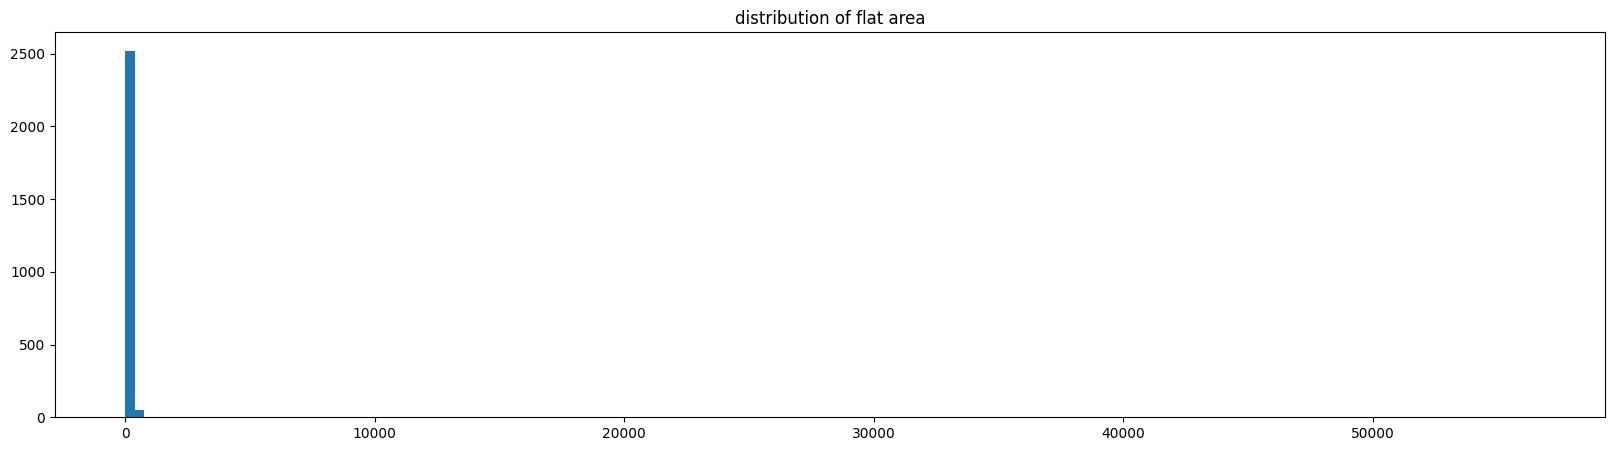

In [16]:
plt.figure(figsize=(20,5))
plt.hist(x=df['area_sqm'], bins=150, log=False)
plt.title("distribution of flat area")
plt.show()

In [17]:
df.columns

Index(['area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room', 'sector',
       'landmark_count', 'has_hospital_or_clinic', 'has_police_stn',
       'has_fire_stn', 'has_mall', 'has_market', 'has_park', 'has_bank_or_atm',
       'has_institute', 'has_airport', 'has_rly_stn', 'has_metro_stn',
       'has_expy', 'has_petrol_pump', 'has_hotel', 'has_temple_or_church',
       'has_famous_chowk', 'has_club', 'has_stadium', 'has_restro_cafe',
       'area_type', 'floor_rise', 'age', 'society', 'city', 'price_cr'],
      dtype='str')

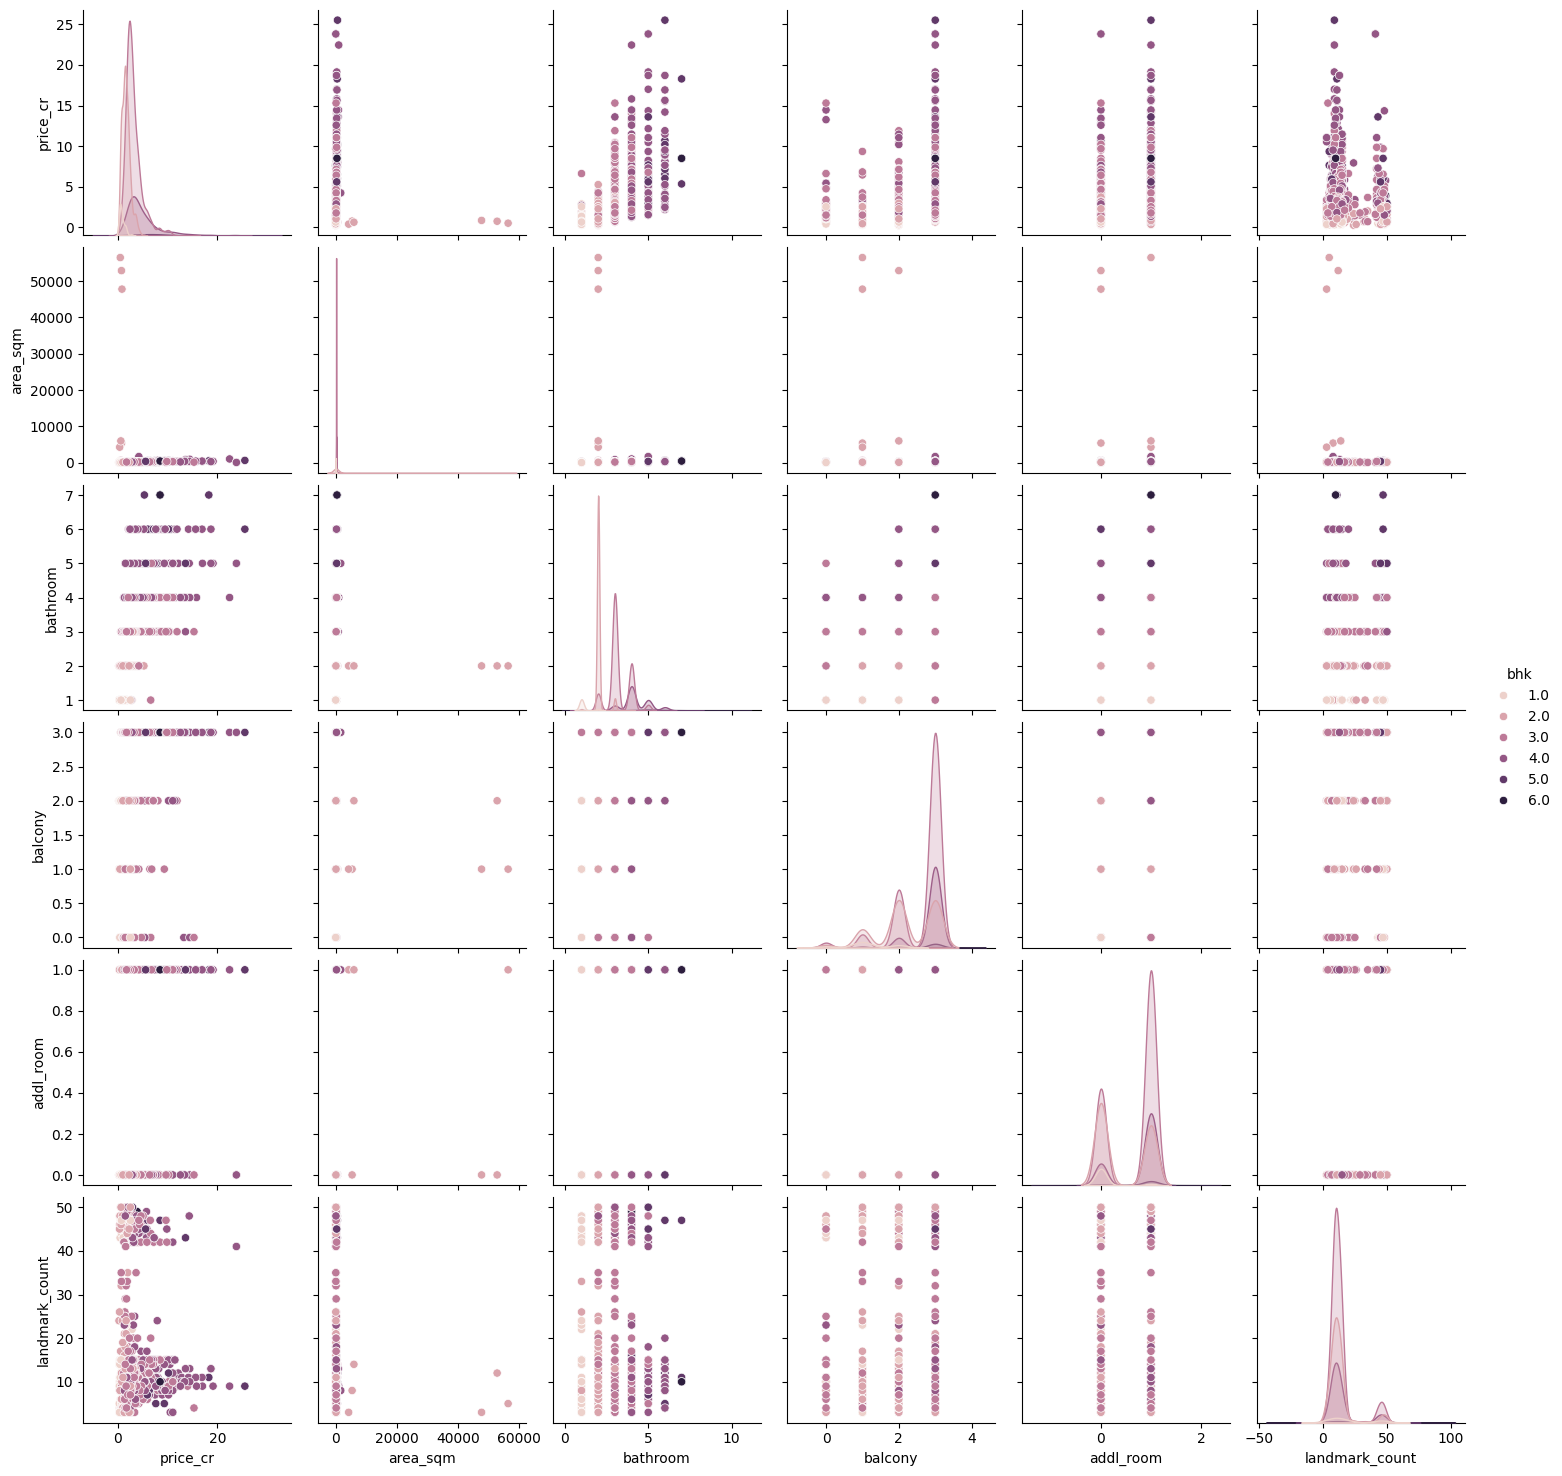

In [18]:
df1 = df[['price_cr', 'area_sqm', 'bhk', 'bathroom', 'balcony', 'addl_room','landmark_count']]
sns.pairplot(df1, hue='bhk')

In [19]:
grp_sector_wise = df.groupby(['city','sector'])[['price_cr','area_sqm','bhk','landmark_count']].mean()
grp_sector_wise = grp_sector_wise.query("city == 'gurgaon'")
grp_sector_wise

price_cr    area_sqm       bhk  landmark_count
city    sector                                                
gurgaon 1.0     2.445703  199.055676  3.081081       16.675676
        2.0     2.708312  130.818750  2.562500       34.062500
        3.0     3.538267  163.996000  2.400000       35.733333
        4.0     2.742313  124.885625  2.562500       43.625000
        5.0     6.903214  194.425000  3.357143       15.214286
...                  ...         ...       ...             ...
        109.0   3.000500  201.856538  3.096154       12.230769
        110.0   5.467389  289.057778  4.000000       14.111111
        111.0   4.436190  203.704286  3.095238       12.666667
        112.0   6.839667  314.749524  3.095238        8.000000
        113.0   4.191884  198.723721  3.046512        9.023256

[85 rows x 4 columns]

In [20]:
df_lat_long = pd.read_csv('data/08_latlong.csv')
df_lat_long['sector_num'] = df_lat_long['sector'].str.extract(r"(\d+)").replace(np.nan, -1).astype('int64')
df_lat_long

,sector,coordinates,sector_num
0,sector 1,"28.3663° N, 76.9456° E",1
1,sector 2,"28.5095° N, 77.0320° E",2
2,sector 3,"28.4909° N, 77.0176° E",3
3,sector 4,"28.4738° N, 77.0107° E",4
4,sector 5,"28.4794° N, 77.0176° E",5
...,...,...,...
124,sector 113,"28.5287° N, 77.0233° E",113
125,sector 114,"28.5334° N, 77.0118° E",114
126,sector 115,"28.5385° N, 77.0061° E",115
127,gwal pahari,"28.4484° N, 77.0210° E",-1


In [21]:
grp_sector_wise = grp_sector_wise.merge(df_lat_long, 'left', left_on='sector', right_on='sector_num')
grp_sector_wise['lat'] = grp_sector_wise['coordinates'].str.split(',').str[0].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise['long'] = grp_sector_wise['coordinates'].str.split(',').str[1].str.extract(r"(\d+\.?\d*)").astype(float)
grp_sector_wise.drop(columns=['coordinates'], inplace=True)
grp_sector_wise

,price_cr,area_sqm,bhk,landmark_count,sector,sector_num,lat,long
0,2.445703,199.055676,3.081081,16.675676,sector 1,1,28.3663,76.9456
1,2.708312,130.818750,2.562500,34.062500,sector 2,2,28.5095,77.0320
2,3.538267,163.996000,2.400000,35.733333,sector 3,3,28.4909,77.0176
3,2.742313,124.885625,2.562500,43.625000,sector 4,4,28.4738,77.0107
4,6.903214,194.425000,3.357143,15.214286,sector 5,5,28.4794,77.0176
...,...,...,...,...,...,...,...,...
90,3.000500,201.856538,3.096154,12.230769,sector 109,109,28.5073,77.0089
91,5.467389,289.057778,4.000000,14.111111,sector 110,110,28.5145,77.0197
92,4.436190,203.704286,3.095238,12.666667,sector 111,111,28.5238,77.0320
93,6.839667,314.749524,3.095238,8.000000,sector 112,112,28.5189,77.0183


In [22]:
grp_sector_wise.dropna(inplace=True)

In [23]:
grp_sector_wise

,price_cr,area_sqm,bhk,landmark_count,sector,sector_num,lat,long
0,2.445703,199.055676,3.081081,16.675676,sector 1,1,28.3663,76.9456
1,2.708312,130.818750,2.562500,34.062500,sector 2,2,28.5095,77.0320
2,3.538267,163.996000,2.400000,35.733333,sector 3,3,28.4909,77.0176
3,2.742313,124.885625,2.562500,43.625000,sector 4,4,28.4738,77.0107
4,6.903214,194.425000,3.357143,15.214286,sector 5,5,28.4794,77.0176
...,...,...,...,...,...,...,...,...
90,3.000500,201.856538,3.096154,12.230769,sector 109,109,28.5073,77.0089
91,5.467389,289.057778,4.000000,14.111111,sector 110,110,28.5145,77.0197
92,4.436190,203.704286,3.095238,12.666667,sector 111,111,28.5238,77.0320
93,6.839667,314.749524,3.095238,8.000000,sector 112,112,28.5189,77.0183


In [24]:
fig = px.scatter_mapbox(grp_sector_wise, lat="lat", lon="long", color="price_cr", size='area_sqm',
                  color_continuous_scale=px.colors.diverging.Portland, zoom=10, width=1000, height=500,
                  mapbox_style="open-street-map", text=grp_sector_wise.index.astype(str))
fig.show()

In [25]:
#sector 44 and 53 seem to be the most expensive sectors on an average.
#sector 50, 45, 22, 98, 64 and 39 seem to be moderately expensive on an average.
#others are cheap

<Axes: title={'center': 'Top 10 Societies by frequency'}, ylabel='society'>

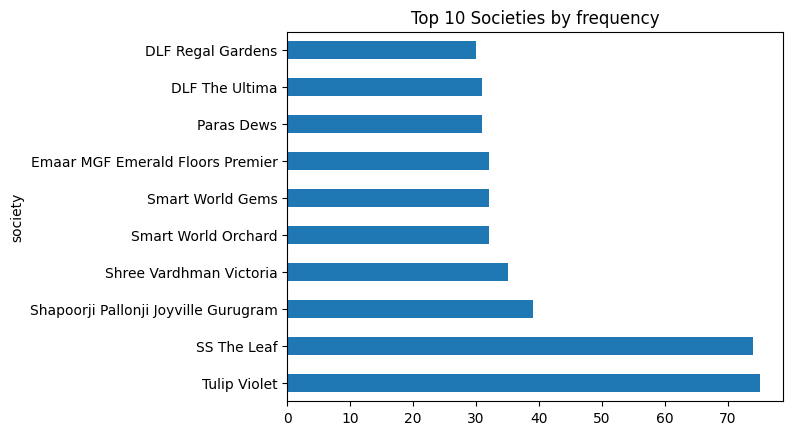

In [26]:
df['society'].value_counts().head(10).plot(kind='barh', title='Top 10 Societies by frequency')

<Axes: title={'center': 'Top 10 Sectors by frequency'}, xlabel='sector'>

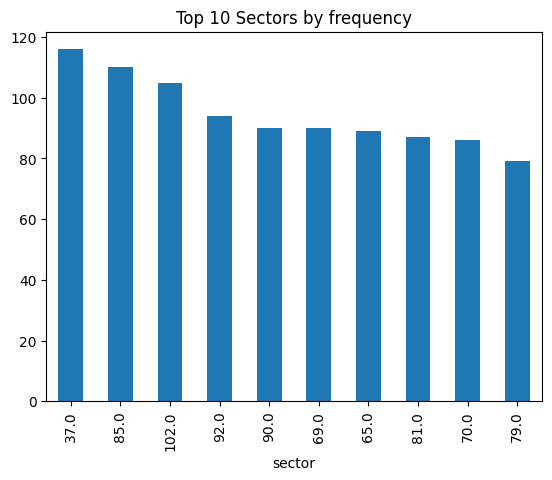

In [27]:
df['sector'].value_counts().head(10).plot(kind='bar', title='Top 10 Sectors by frequency')

<Axes: xlabel='price_cr', ylabel='Count'>

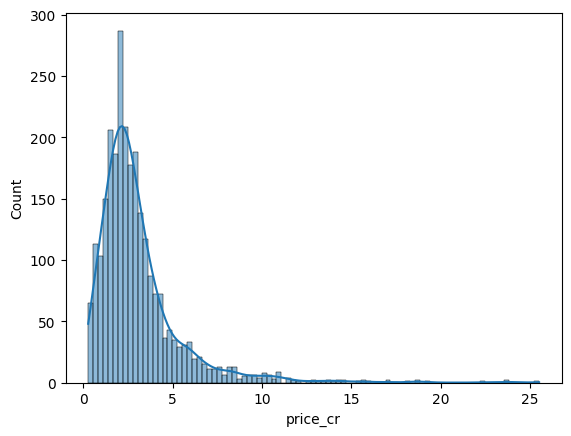

In [28]:
sns.histplot(df['price_cr'], kde=True)

In [29]:
print("Price Skewness: ", df['price_cr'].skew())

Price Skewness:  3.0781182615504177


In [30]:
print("Price Kurtosis: ", df['price_cr'].kurt())

Price Kurtosis:  15.752643130985224


In [31]:
quantiles = df['price_cr'].quantile([0.01, 0.1, 0.25, 0.50, 0.75, 0.90, 0.99])
quantiles

0.01     0.442
0.10     1.020
0.25     1.666
0.50     2.465
0.75     3.570
0.90     5.644
0.99    12.240
Name: price_cr, dtype: float64

In [32]:
#50% flats are below 1.4 Crore Rupees

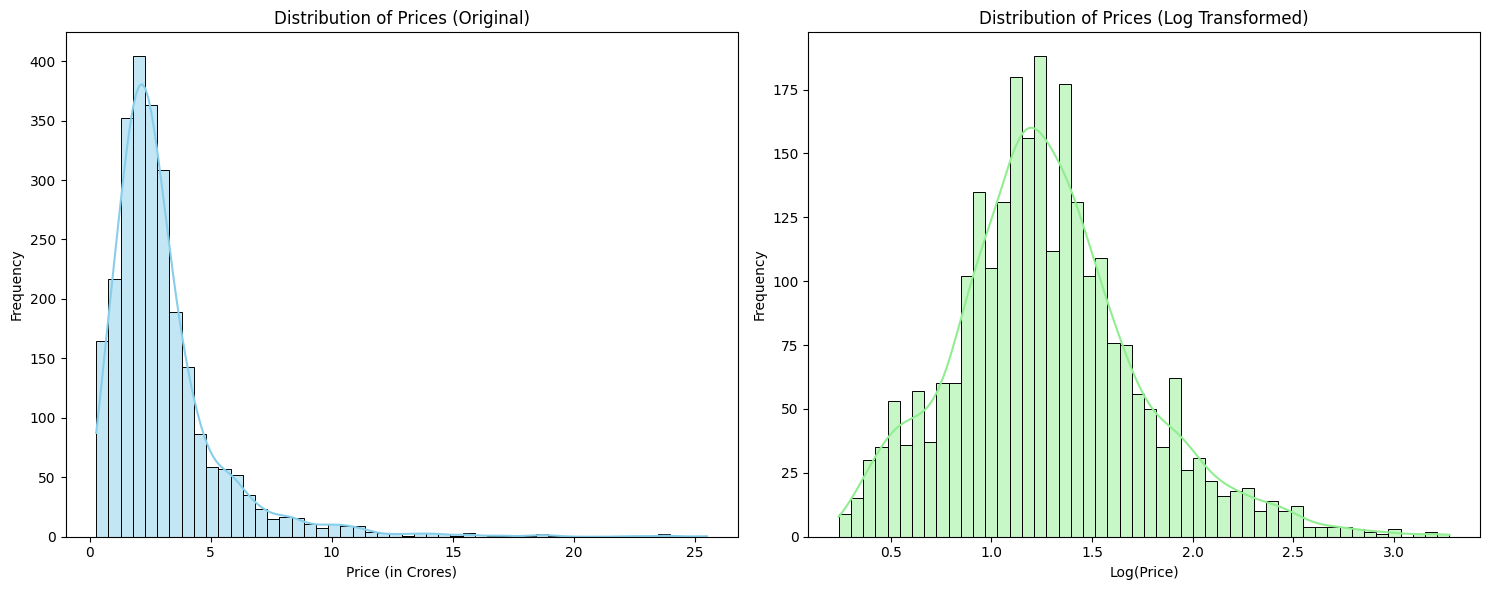

In [33]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_cr'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_cr']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

<Axes: xlabel='price_cr'>

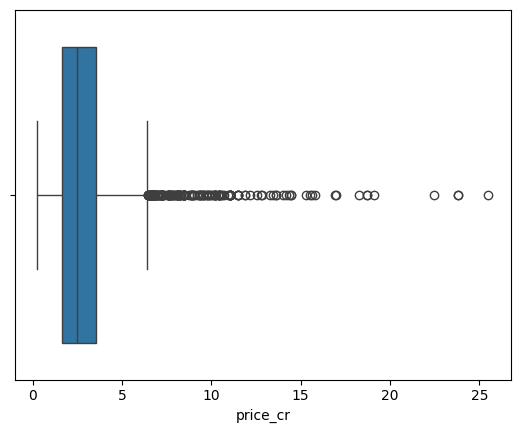

In [34]:
sns.boxplot(x=df['price_cr'])

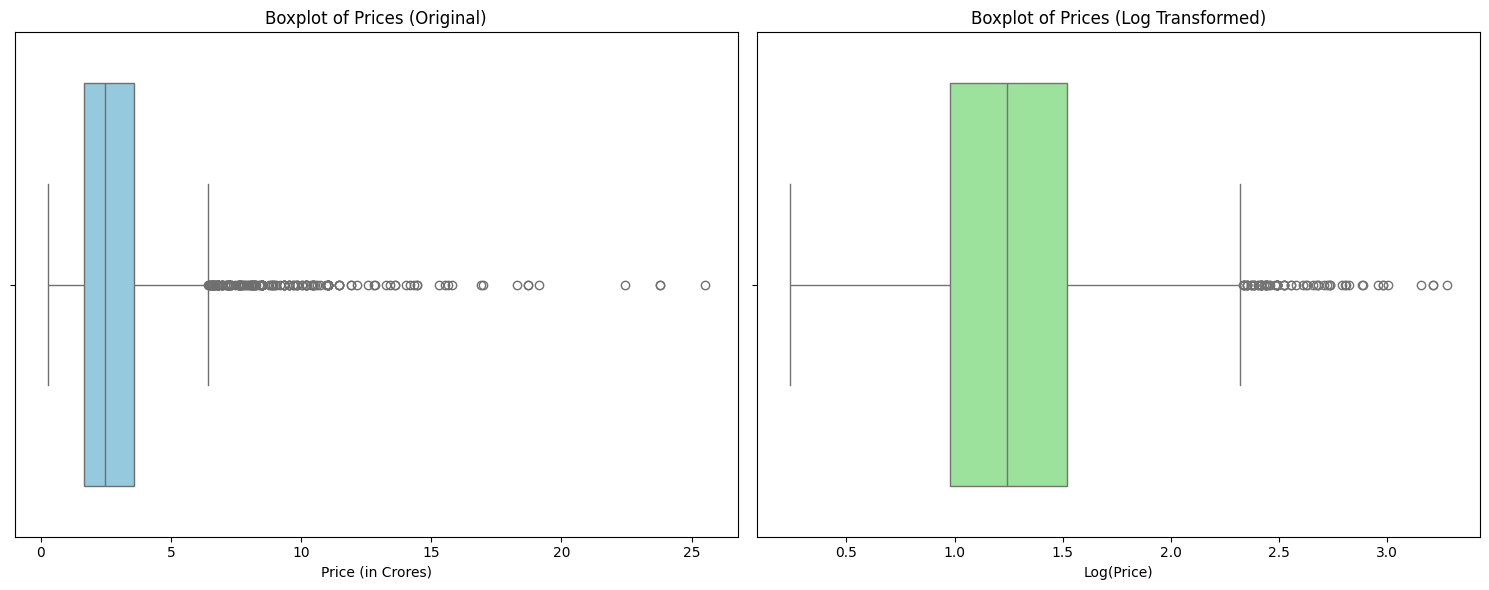

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price_cr'], color='skyblue')
plt.title('Boxplot of Prices (Original)')
plt.xlabel('Price (in Crores)')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price_cr']), color='lightgreen')
plt.title('Boxplot of Prices (Log Transformed)')
plt.xlabel('Log(Price)')

plt.tight_layout()
plt.show()

<Axes: title={'center': '#Flats for each bhk type'}, ylabel='bhk'>

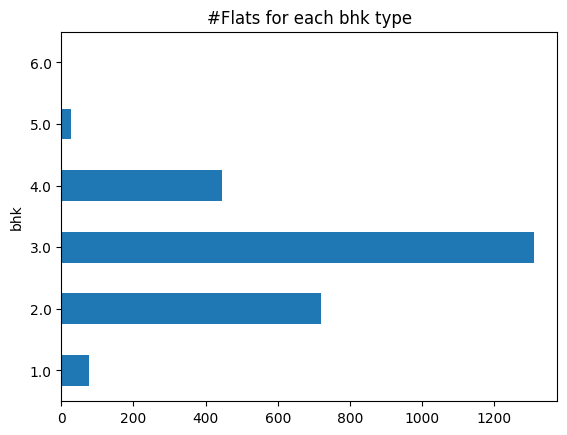

In [36]:
df['bhk'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bhk type')

<Axes: title={'center': '#Flats for each bathroom type'}, ylabel='bathroom'>

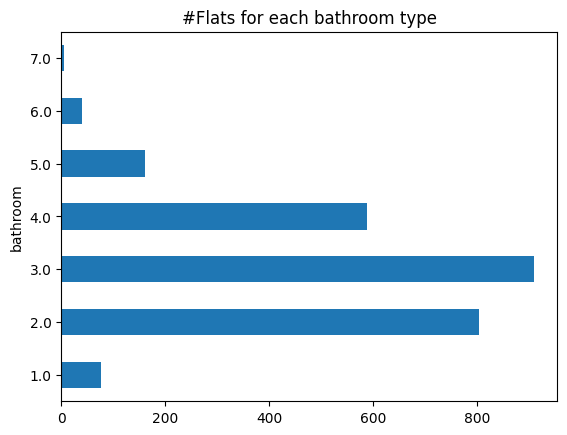

In [37]:
df['bathroom'].value_counts().sort_index().plot(kind='barh', title='#Flats for each bathroom type')

<Axes: title={'center': '#bathroom proportion'}>

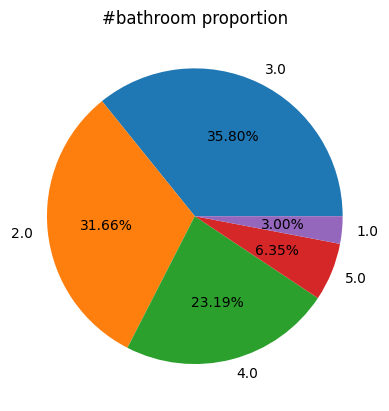

In [38]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%',
                                                        title='#bathroom proportion')

<Axes: title={'center': '#Flats for each balcony type'}, ylabel='balcony'>

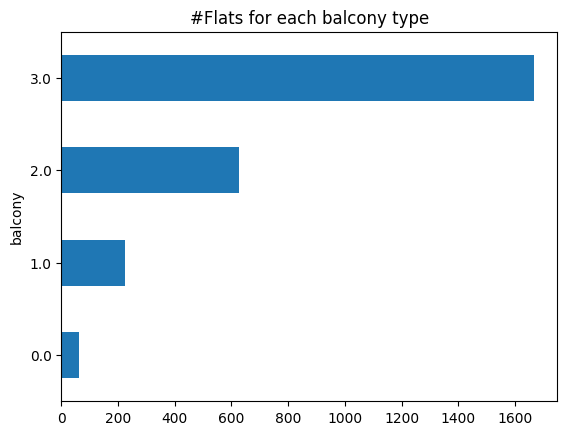

In [39]:
df['balcony'].value_counts().sort_index().plot(kind='barh', title='#Flats for each balcony type')

<Axes: xlabel='floor_rise'>

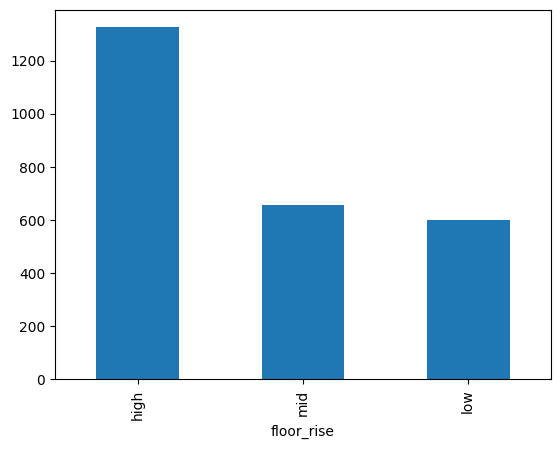

In [40]:
df['floor_rise'].value_counts().plot(kind='bar')

<Axes: ylabel='age'>

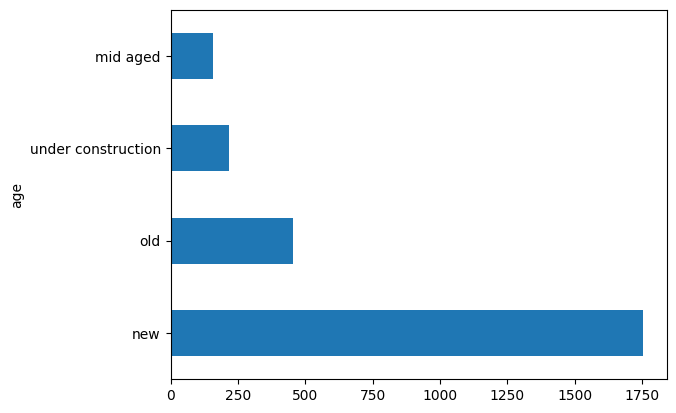

In [41]:
df['age'].value_counts().plot(kind='barh')

<Axes: >

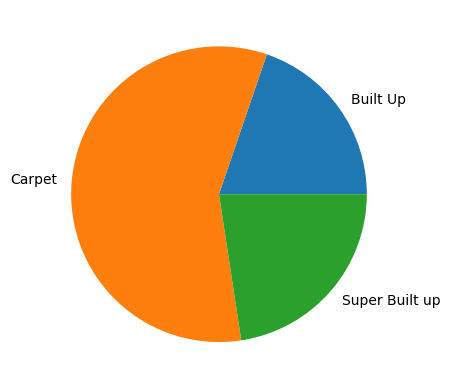

In [42]:
df.groupby('area_type')['area_sqm'].mean().plot(kind='pie')

In [43]:
#from ydata_profiling import ProfileReport
#profile = ProfileReport(df, title='Pandas Profiling Report', explorative=True)
#profile.to_file('10_df_profiling.html')


In [44]:
'''
profile = ProfileReport(
    df,
    title="10_df_profiling",
    dataset={
        "description": "99 Acres Dataset Description",
        "author": "Gaurav Singh",
    },
    variables={
        "descriptions": {
            "col1": "Description of all columns",
        }
    },
    explorative=True,   # deeper analysis
    minimal=False,      # set True for large datasets
)
profile.to_file("10_df_profiling.html")
'''

'\nprofile = ProfileReport(\n    df,\n    title="10_df_profiling",\n    dataset={\n        "description": "99 Acres Dataset Description",\n        "author": "Gaurav Singh",\n    },\n    variables={\n        "descriptions": {\n            "col1": "Description of all columns",\n        }\n    },\n    explorative=True,   # deeper analysis\n    minimal=False,      # set True for large datasets\n)\nprofile.to_file("10_df_profiling.html")\n'

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)



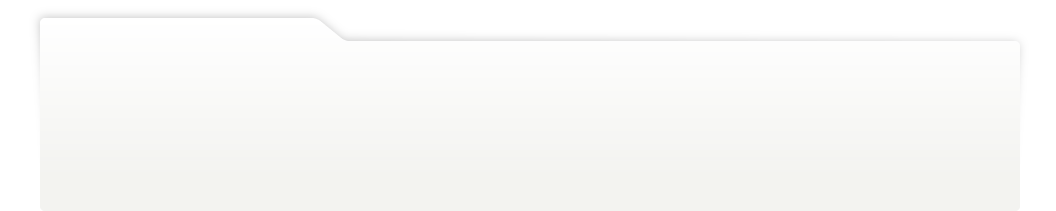
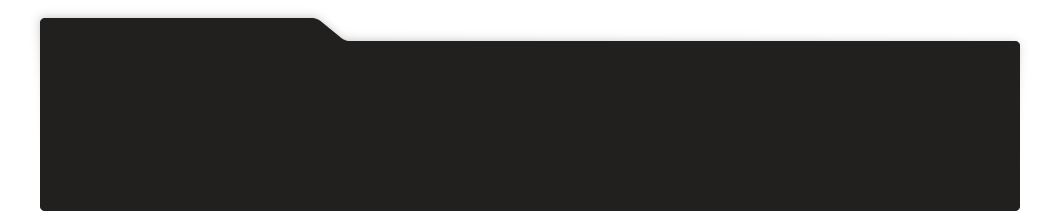
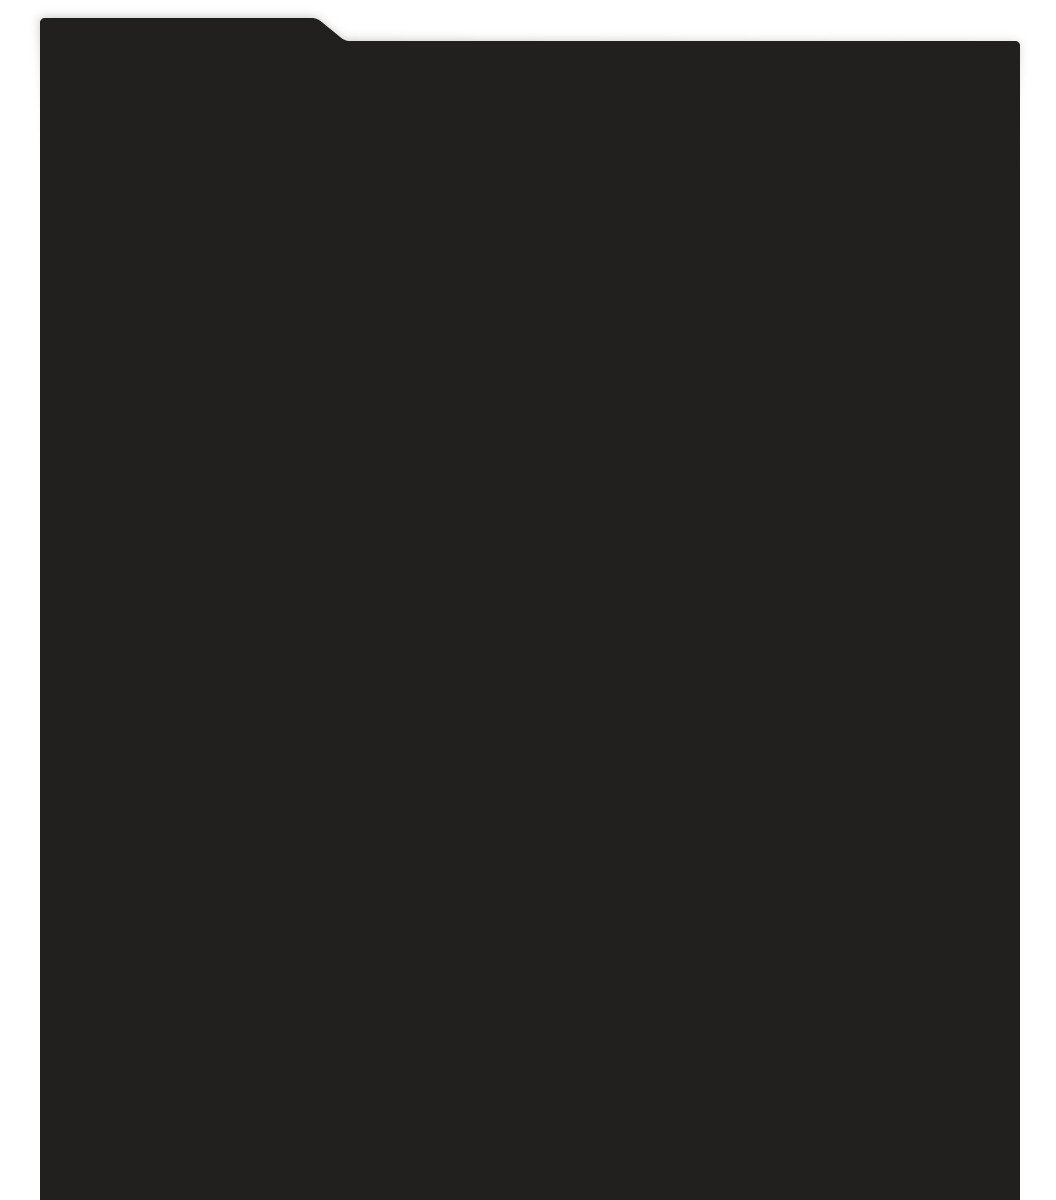
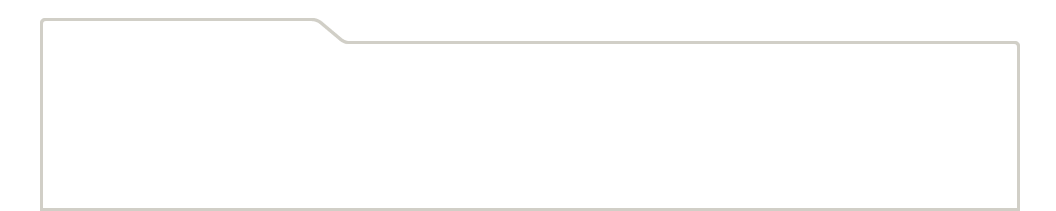
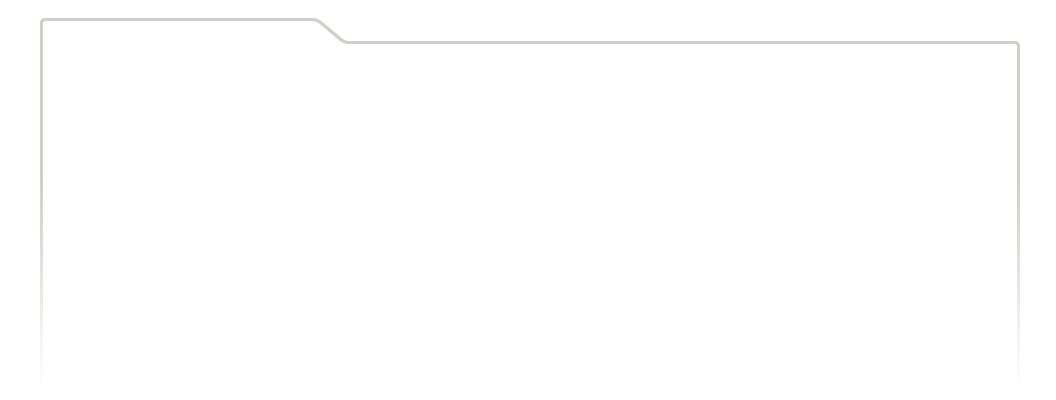
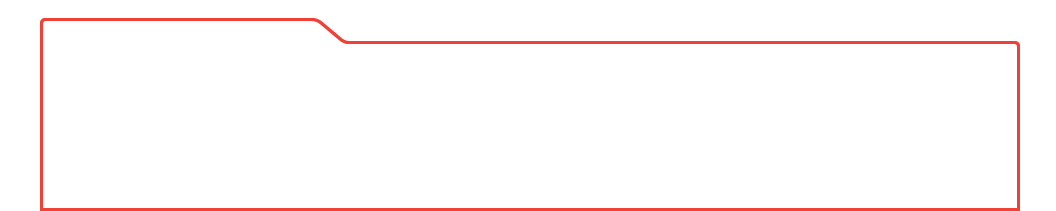
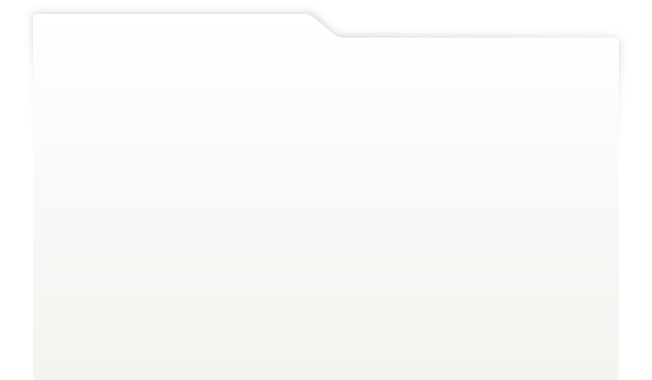
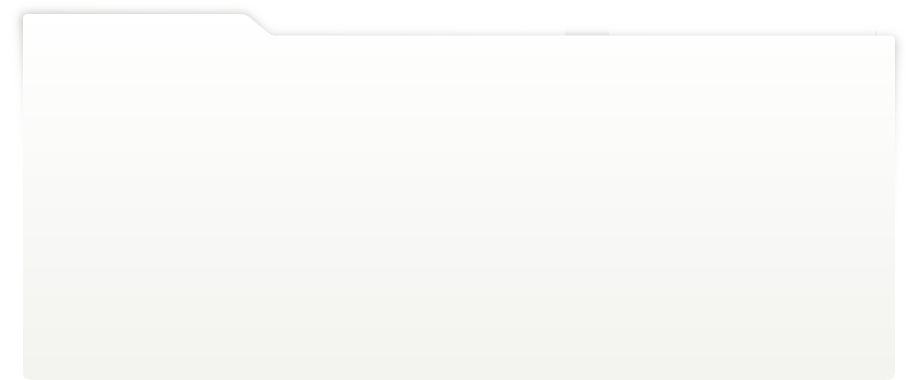
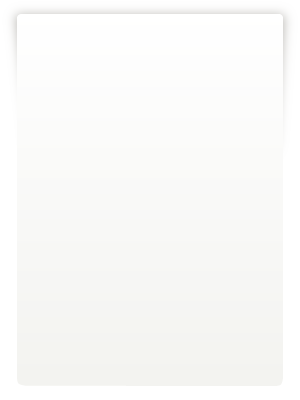
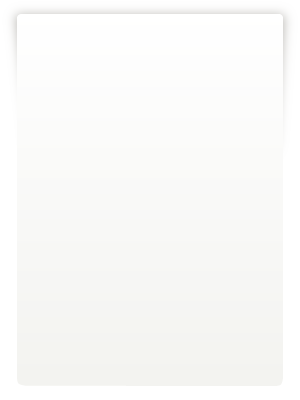
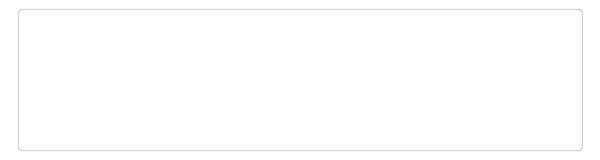
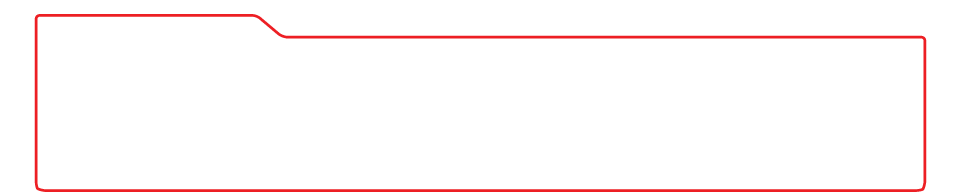
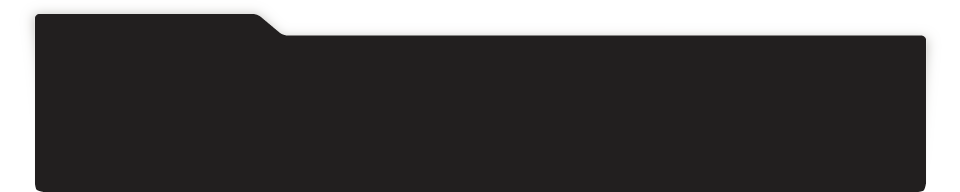
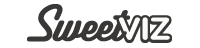
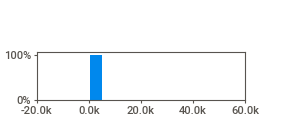
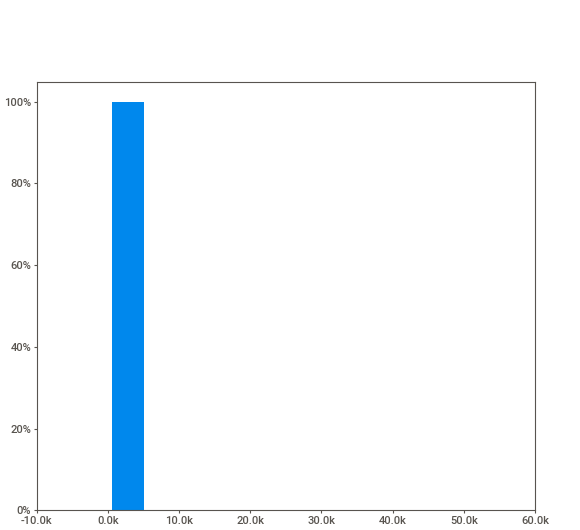
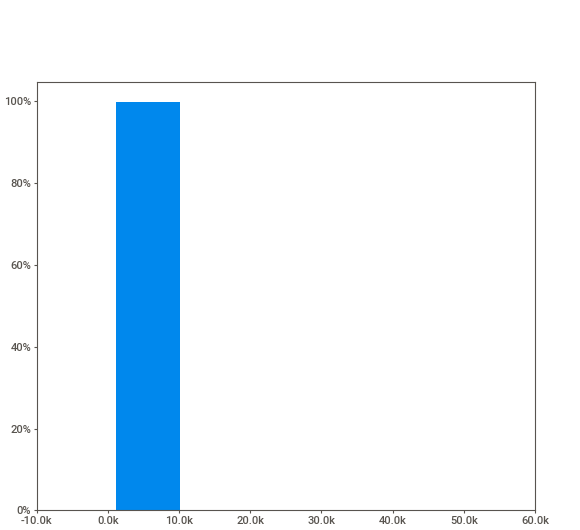
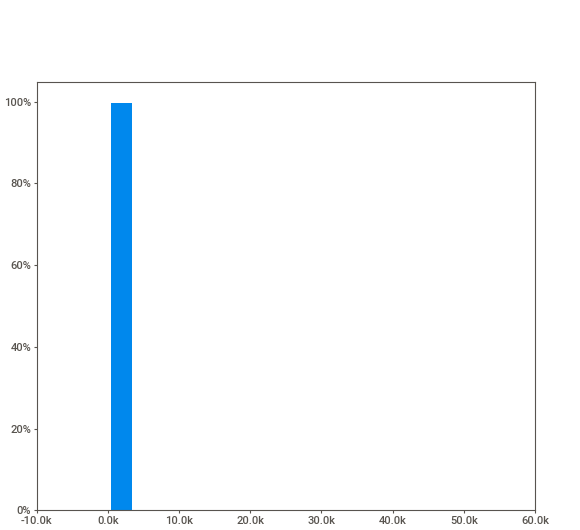
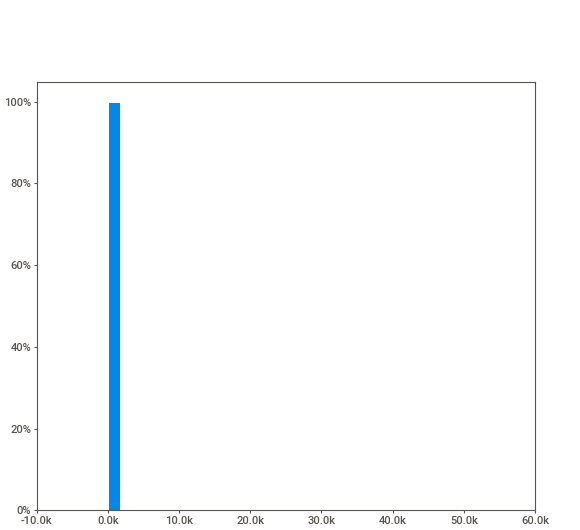
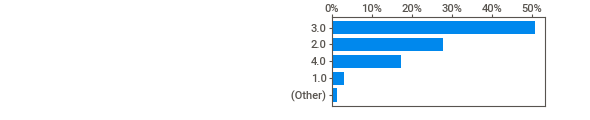
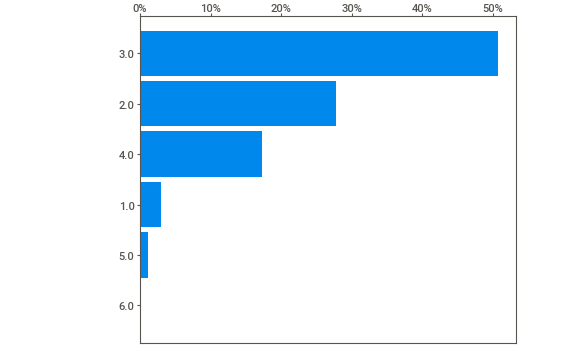
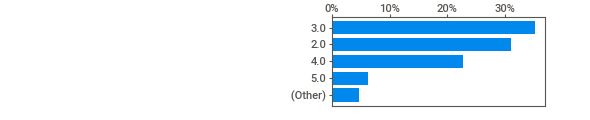
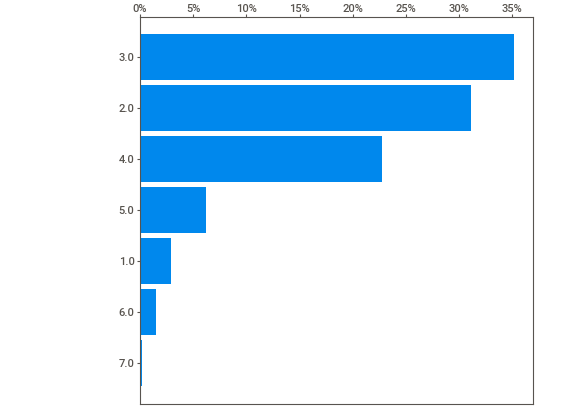
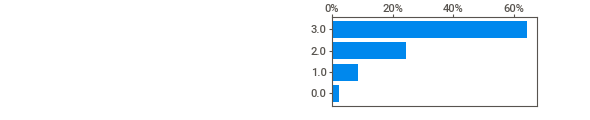
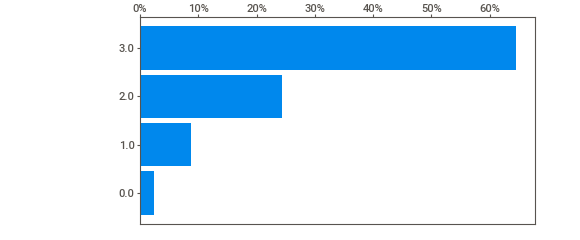
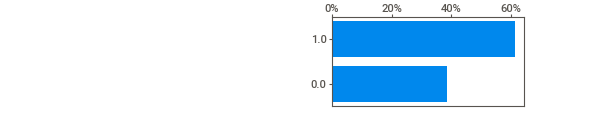
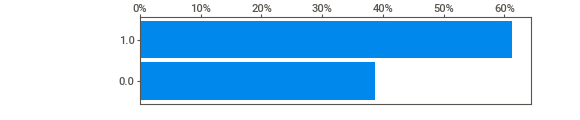
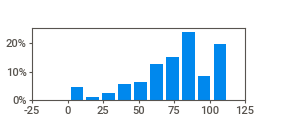
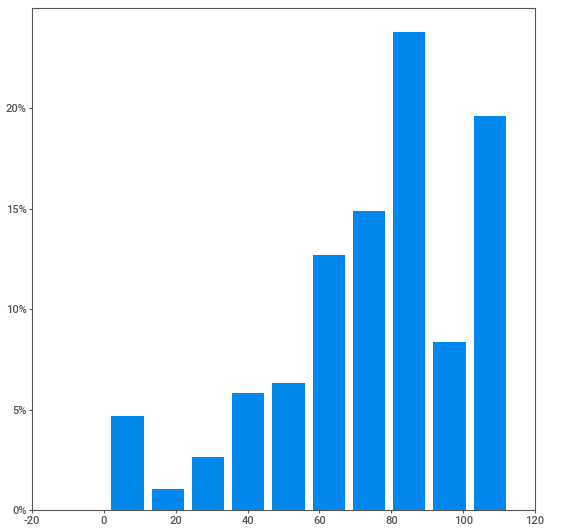
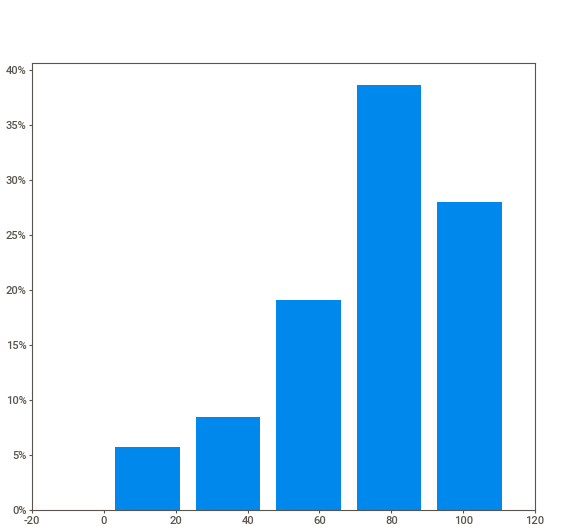
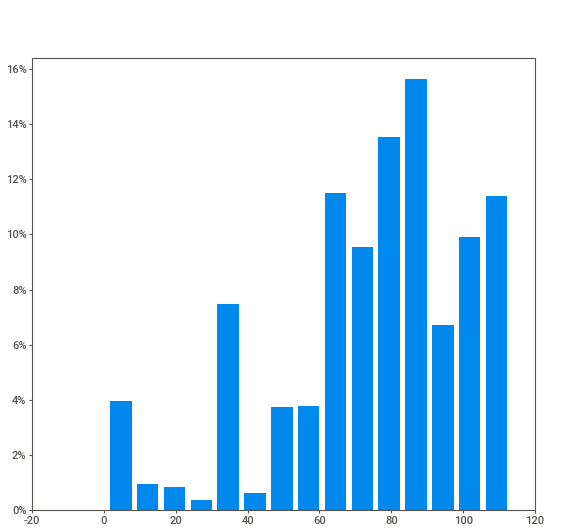
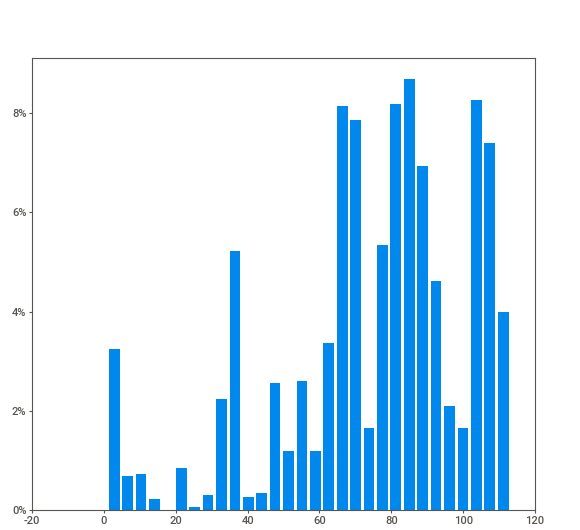
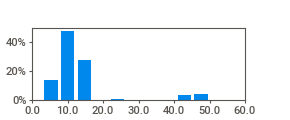
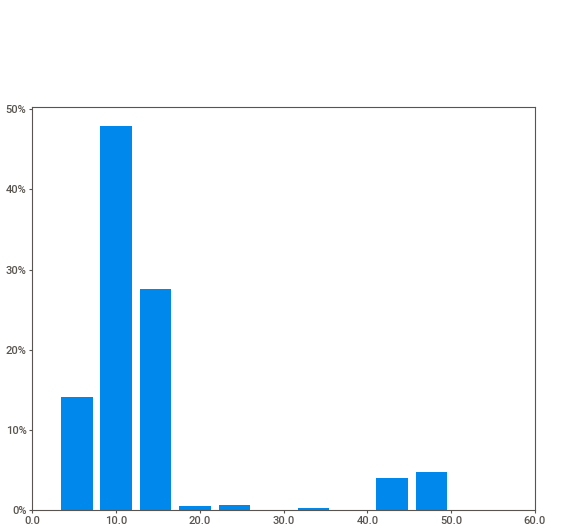
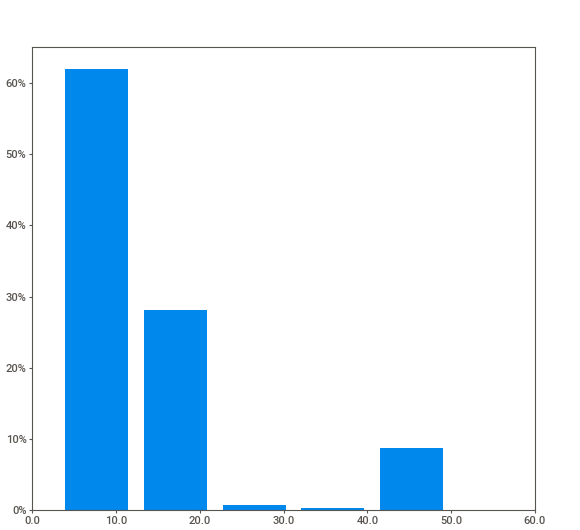
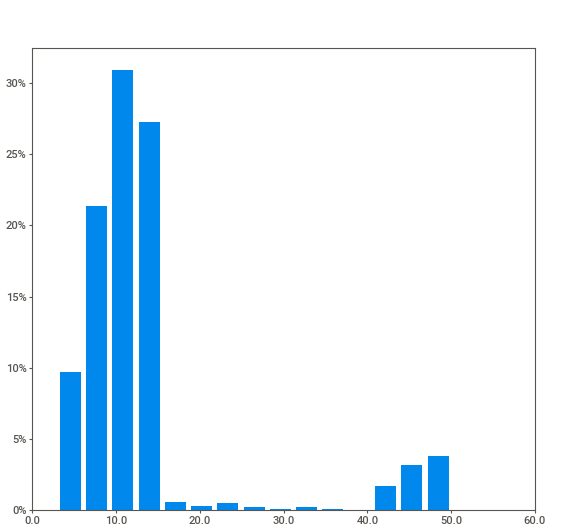
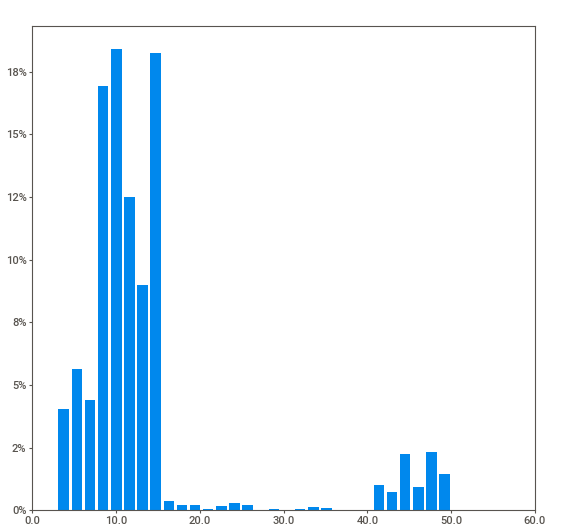
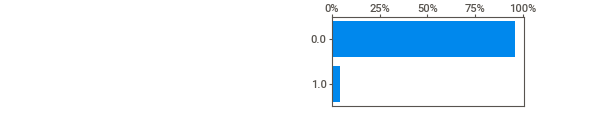
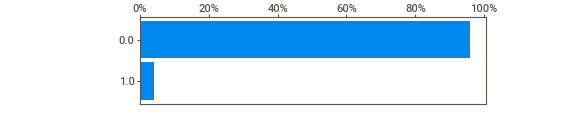
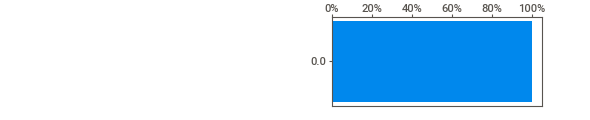
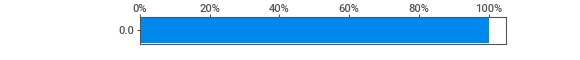
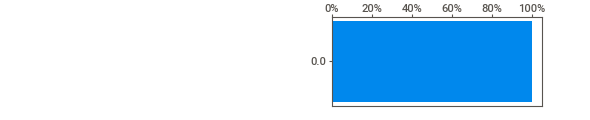
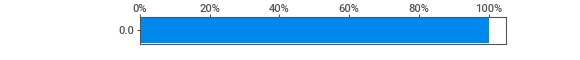
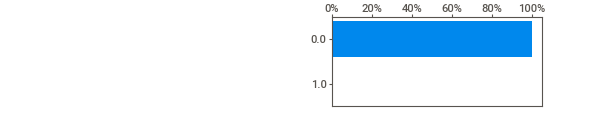
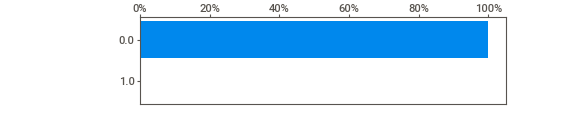
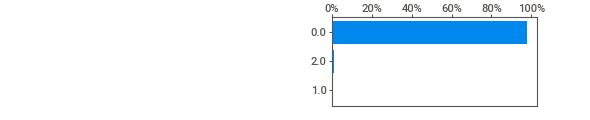
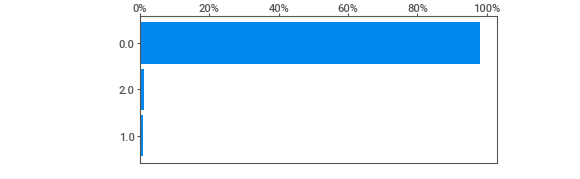
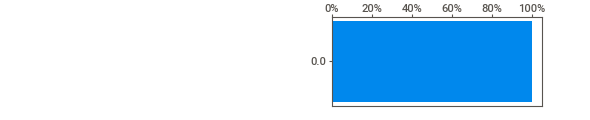
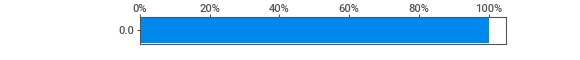
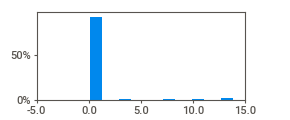
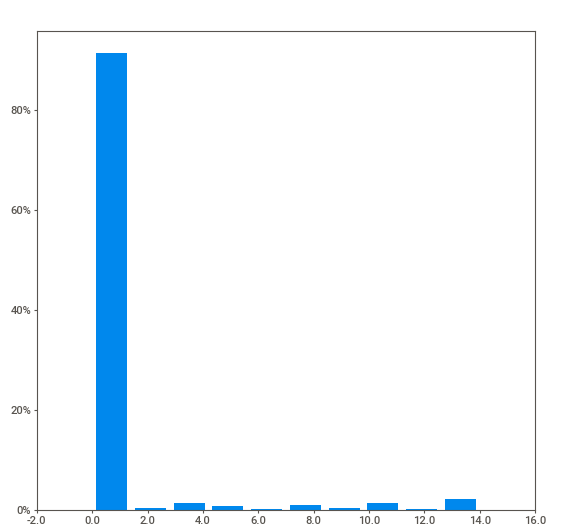
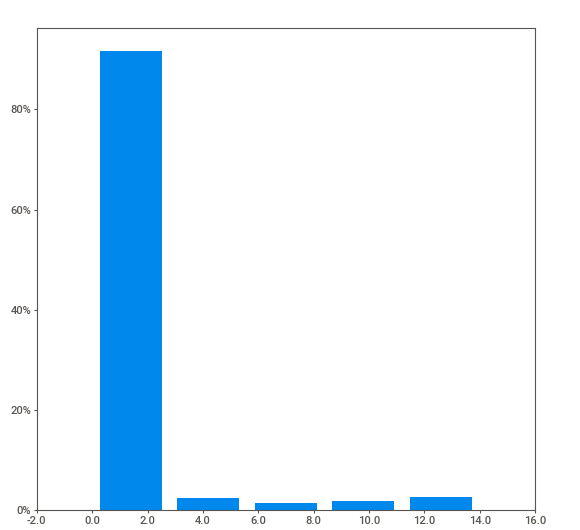
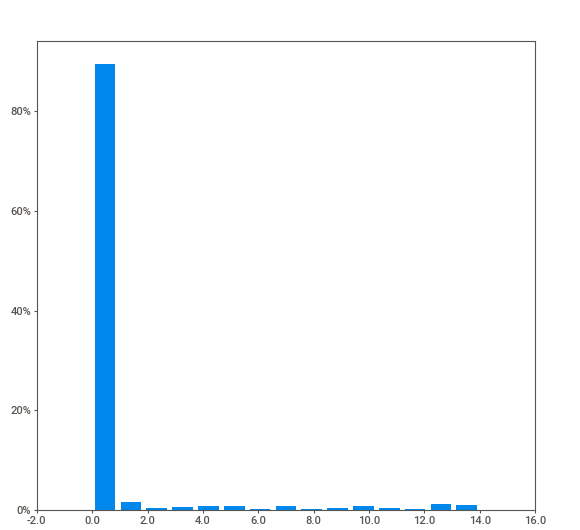
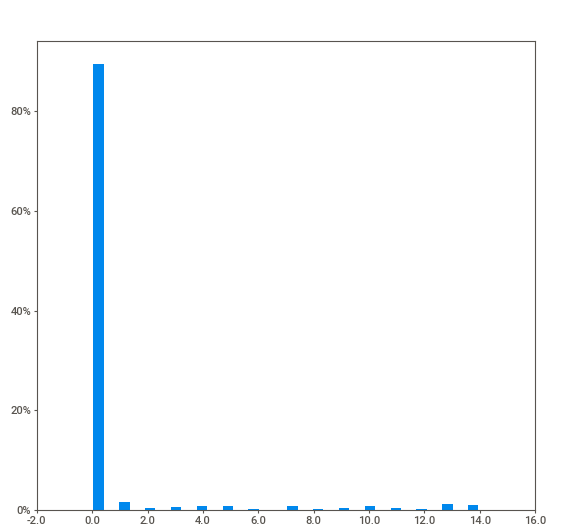
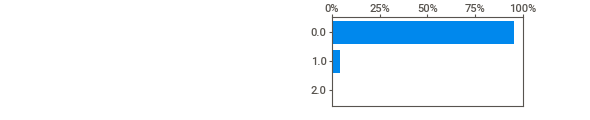
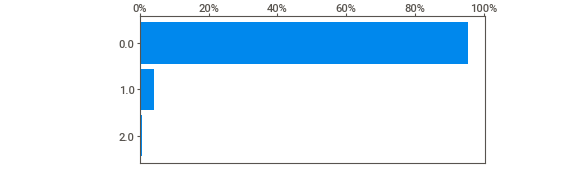
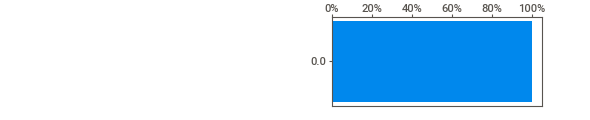
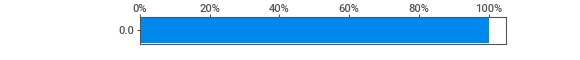
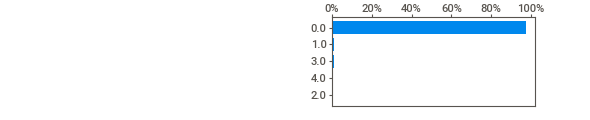
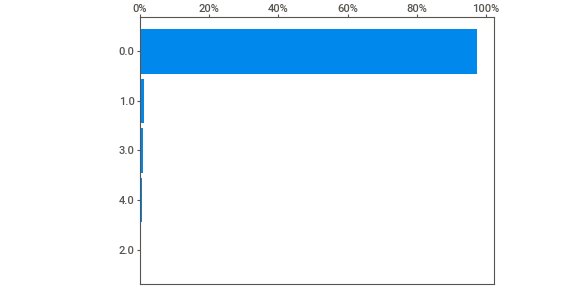
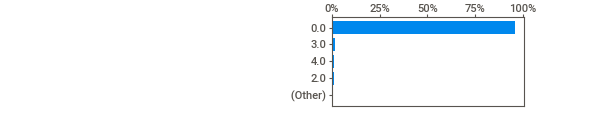
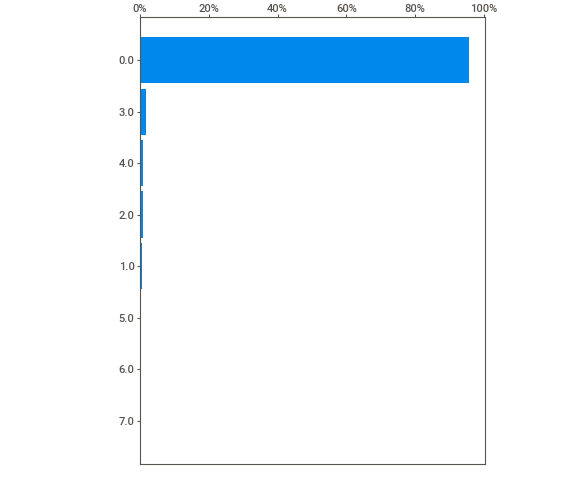
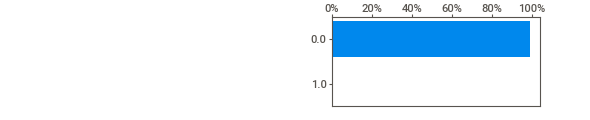
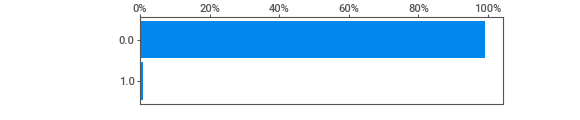
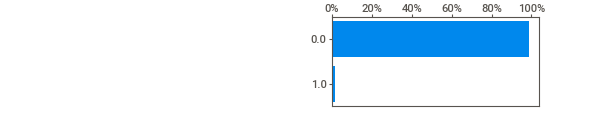
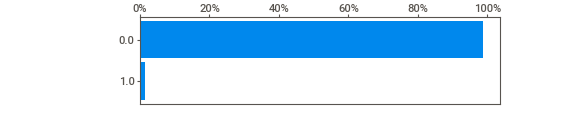
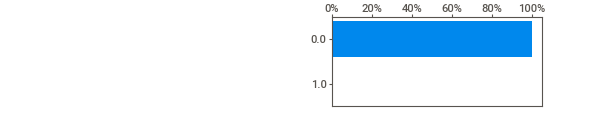
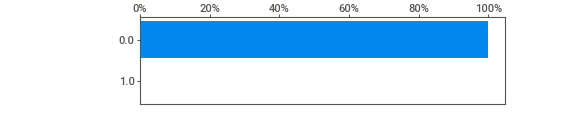
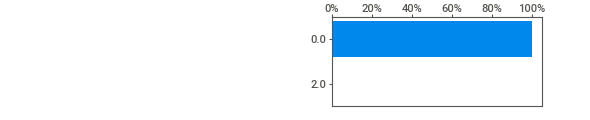
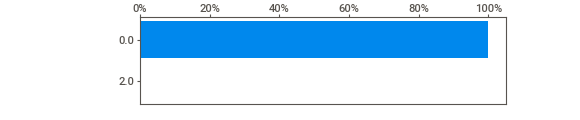
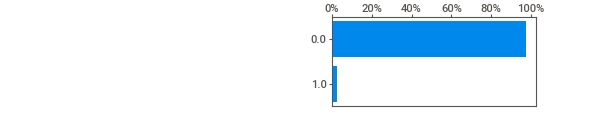
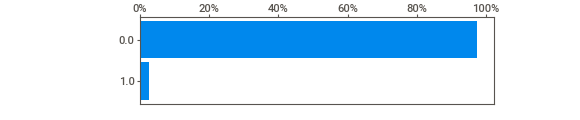
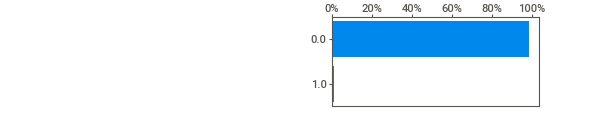
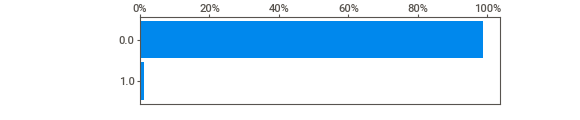
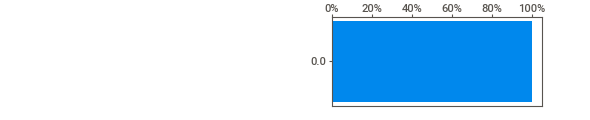
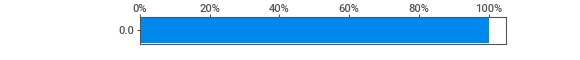
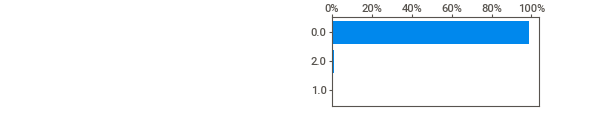
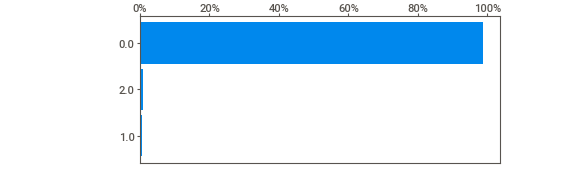
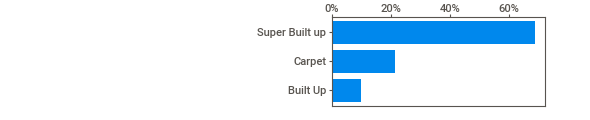
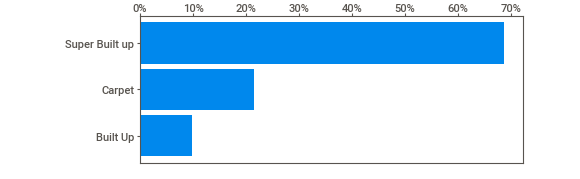
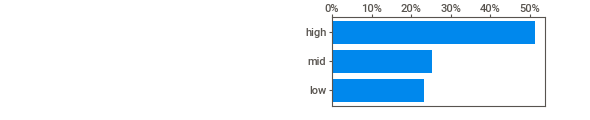
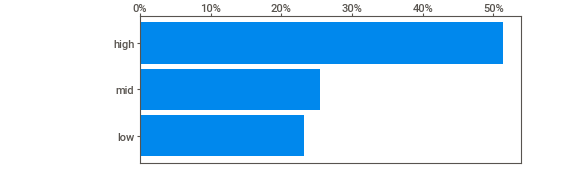
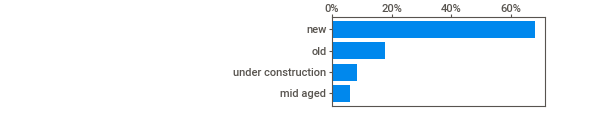
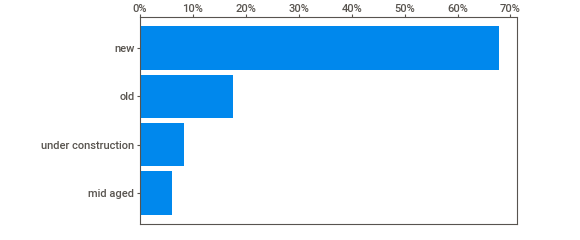
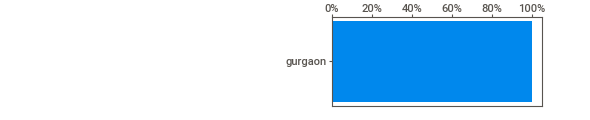
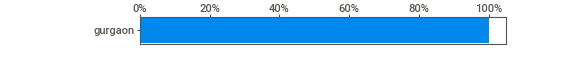
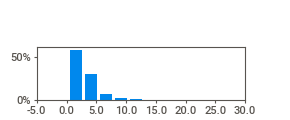
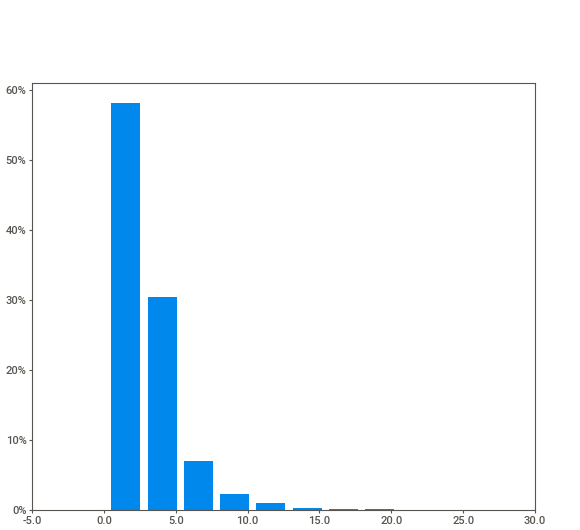
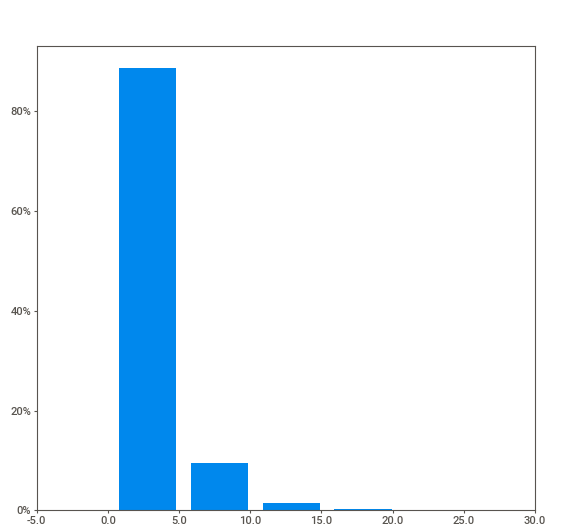
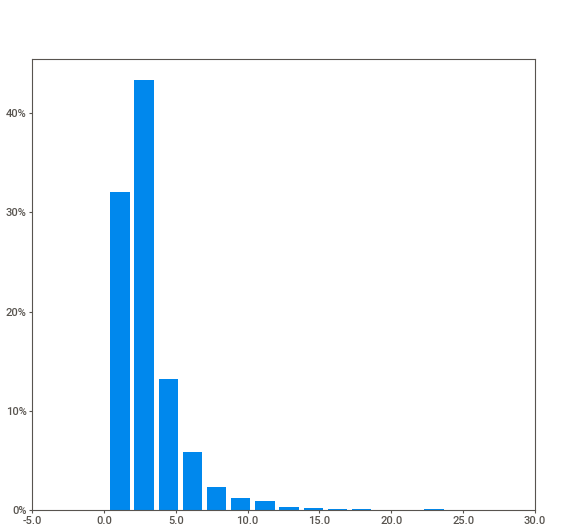
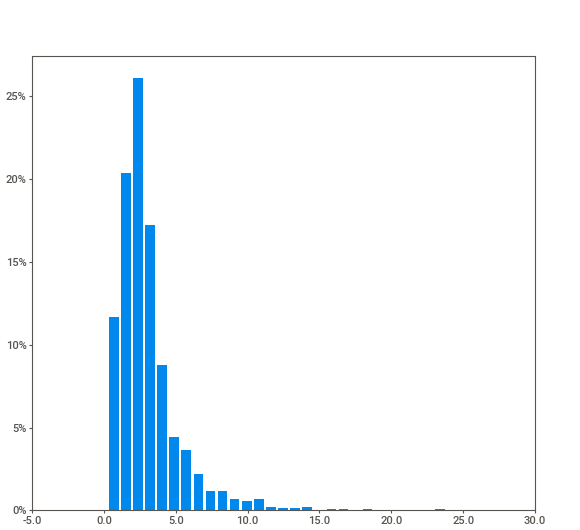
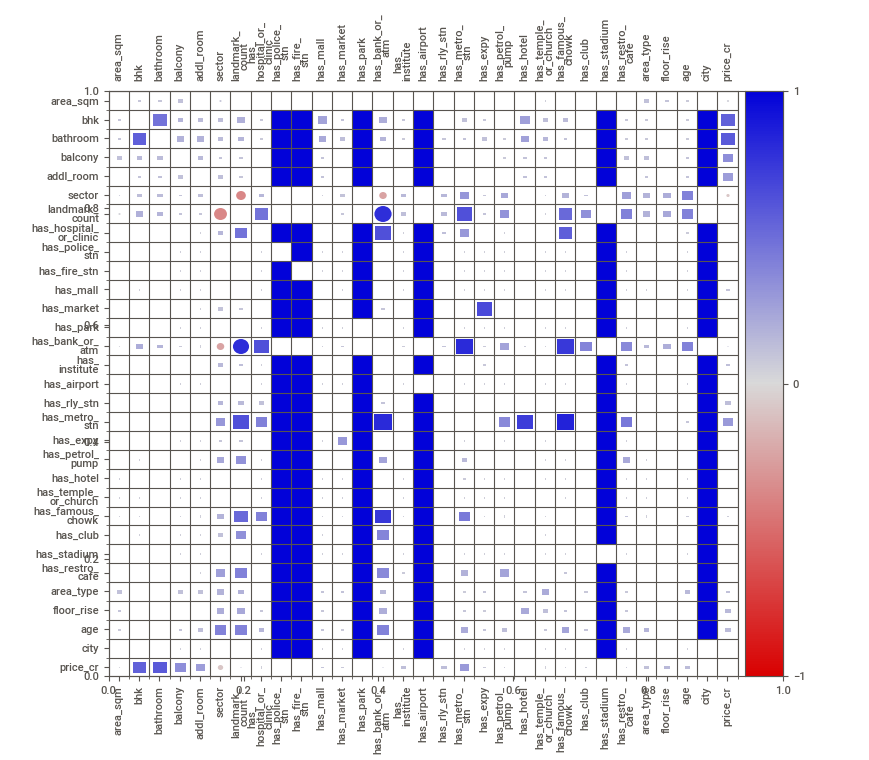
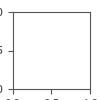

In [45]:
report = sv.analyze(df)
report.show_notebook()